In [1]:
import pickle 
import pandas as pd
import numpy as np 

%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
path = '../attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4_corrs.pkl'

with open(path, 'rb') as f:
    corrs  = pickle.load(f)

In [3]:
corrs.keys()

dict_keys(['fg_corr_results', 'bg_corr_results'])

In [4]:


fg_corr_results = corrs['fg_corr_results']

bg_corr_results = corrs['bg_corr_results']


# put into df for easy plotting:

dfs = []
for layer in fg_corr_results.keys():
    df = pd.DataFrame.from_dict({'fg_corrs':fg_corr_results[layer],
                                 'bg_corrs':bg_corr_results[layer],
                                 'layer': [layer] * len(fg_corr_results[layer])})
            
    dfs.append(df)

In [5]:
corr_results = pd.concat(dfs)


In [6]:

results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")

In [7]:

results['Stream'].replace('fg_corrs','target',inplace=True)
results['Stream'].replace('bg_corrs','distractor',inplace=True)


In [8]:
order = np.sort(results.layer.unique())

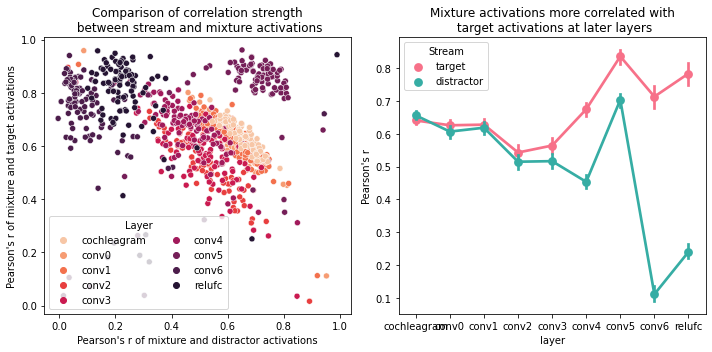

In [9]:
fig, axs = plt.subplots(1,2, figsize=(10,5))



# order = results.layer.unique()


sns.scatterplot(data=corr_results, x='bg_corrs', y='fg_corrs', hue_order=order,
                hue='layer', palette='rocket_r', ax=axs[0])

sns.pointplot(data=results, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', ax=axs[1],
             ci=95, n_boot=10000, seed=1)

axs[0].set_title("Comparison of correlation strength\n between stream and mixture activations")
axs[0].set_xlabel("Pearson's r of mixture and distractor activations")
axs[0].set_ylabel("Pearson's r of mixture and target activations")
axs[0].legend(title='Layer', ncol=2, frameon=True)

axs[1].set_title("Mixture activations more correlated with\n target activations at later layers")
# axs[1].set_ylabel("Pearson's r")

plt.tight_layout()

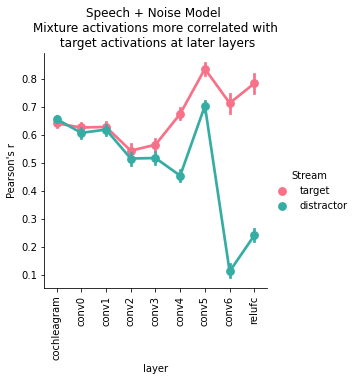

In [9]:

p = sns.catplot(kind='point',data=results, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=4,
             ci=95, n_boot=10000, seed=1)

plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")
p.set_xticklabels(rotation=90)


Text(0.5, 0.98, 'Mixture activations more correlated with\n target activations at later layers')

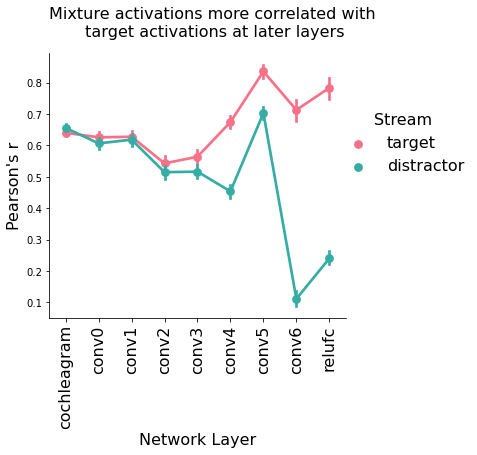

In [39]:
fontsize=16
p = sns.catplot(kind='point',data=results, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=5, aspect=1,
             ci=95, n_boot=10000, seed=1)

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers",
               size=fontsize)
# p.fig.tight_layout()

In [33]:
# p.fig.savefig('../demo_plots/model_layer_corrs.pdf')